In [ ]:
!pip install scikit-learn streamlit


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import plotly as py
import streamlit as st

In [13]:
df=pd.read_csv("/content/AI_Startup_Success_Pattern99.csv")
df.head()




,Startup_ID,Industry,Founder_Experience,Team_Size,Funding_USD,Market_Size,AI_Adoption,Customer_Growth,Burn_Rate,Revenue,Investor_Support,Product_Innovation,Competition_Level,Success
0,ST001,FinTech,10,11,878004,Small,High,83,16,161909,Yes,9,Medium,1
1,ST002,E-commerce,1,7,959420,Small,High,53,18,514706,No,2,Low,0
2,ST003,SaaS,1,38,1277969,Small,Medium,50,16,473642,Yes,1,Medium,0
3,ST004,SaaS,9,37,1761541,Large,Low,87,33,226123,Yes,10,Medium,1
4,ST005,FinTech,1,15,1091056,Medium,Medium,87,78,906726,No,6,High,0


In [14]:
df.describe().sum()
df.duplicated().sum()

np.int64(0)

In [15]:
dataset = pd.DataFrame(df)
dataset.head()

,Startup_ID,Industry,Founder_Experience,Team_Size,Funding_USD,Market_Size,AI_Adoption,Customer_Growth,Burn_Rate,Revenue,Investor_Support,Product_Innovation,Competition_Level,Success
0,ST001,FinTech,10,11,878004,Small,High,83,16,161909,Yes,9,Medium,1
1,ST002,E-commerce,1,7,959420,Small,High,53,18,514706,No,2,Low,0
2,ST003,SaaS,1,38,1277969,Small,Medium,50,16,473642,Yes,1,Medium,0
3,ST004,SaaS,9,37,1761541,Large,Low,87,33,226123,Yes,10,Medium,1
4,ST005,FinTech,1,15,1091056,Medium,Medium,87,78,906726,No,6,High,0


In [16]:
df.drop_duplicates()
df.isnull().sum()


,0
Startup_ID,0
Industry,0
Founder_Experience,0
Team_Size,0
Funding_USD,0
Market_Size,0
AI_Adoption,0
Customer_Growth,0
Burn_Rate,0
Revenue,0


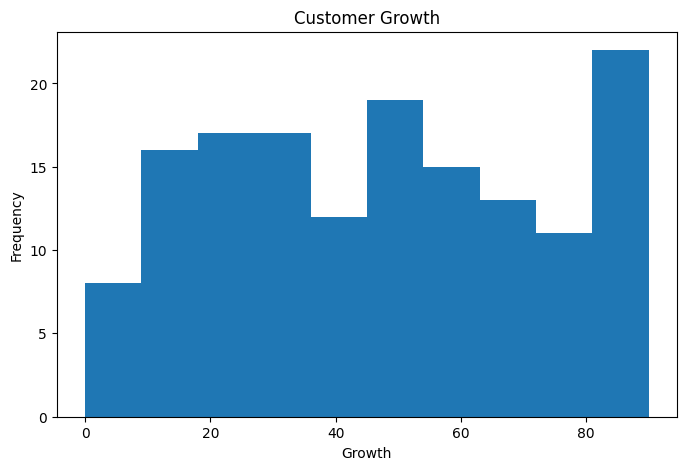

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Customer_Growth"], bins=10)
plt.title("Customer Growth")
plt.xlabel("Growth")
plt.ylabel("Frequency")

plt.show()

In [18]:
df["Funding_per_Employee"] = df["Funding_USD"] / df["Team_Size"]
df[["Funding_USD","Team_Size","Funding_per_Employee"]].head()

,Funding_USD,Team_Size,Funding_per_Employee
0,878004,11,79818.545455
1,959420,7,137060.000000
2,1277969,38,33630.763158
3,1761541,37,47609.216216
4,1091056,15,72737.066667


In [19]:
df.select_dtypes(include="object").columns

Index(['Startup_ID', 'Industry', 'Market_Size', 'AI_Adoption',
       'Investor_Support', 'Competition_Level'],
      dtype='object')

In [20]:
X = df.drop("Success", axis=1)
y = df["Success"]

In [21]:
X = X.drop('Startup_ID', axis=1)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train["Industry"]=le.fit_transform(X_train["Industry"])
X_test["Industry"]=le.transform(X_test["Industry"])

In [24]:
x_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train,X_test = x_train.align(X_test,join='inner',axis=1,fill_value=0)

In [25]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [26]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)





Accuracy: 0.8666666666666667


In [27]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [28]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42,eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.48214285714285715
[[27  1]
 [ 2  0]]


In [36]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,  # Changed from X.columns to X_train.columns
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
4            Customer_Growth    0.144483
3                Funding_USD    0.122820
2                  Team_Size    0.097199
5                  Burn_Rate    0.094769
1         Founder_Experience    0.093330
7         Product_Innovation    0.091770
8       Funding_per_Employee    0.087748
6                    Revenue    0.077573
0                   Industry    0.049159
16      Investor_Support_Yes    0.018455
19  Competition_Level_Medium    0.018039
10        Market_Size_Medium    0.014782
18     Competition_Level_Low    0.014318
15       Investor_Support_No    0.013331
12          AI_Adoption_High    0.011836
14        AI_Adoption_Medium    0.011454
11         Market_Size_Small    0.009985
13           AI_Adoption_Low    0.009941
17    Competition_Level_High    0.009546
9          Market_Size_Large    0.009461


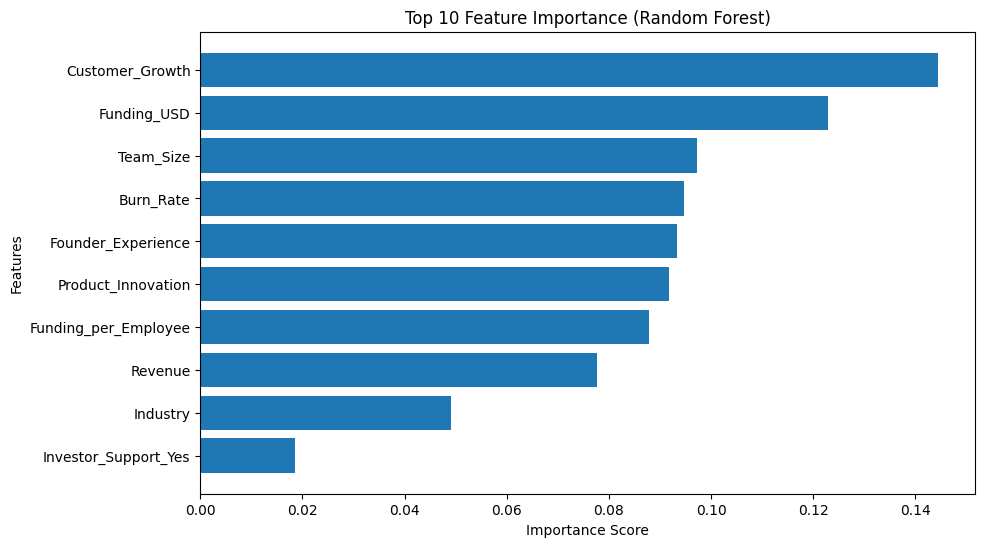

In [37]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance (Random Forest)")

plt.gca().invert_yaxis()

plt.show()